In [ ]:
!pip install numpy pandas scikit-learn xgboost matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nipungarg1409","key":"fe675e10b2f386c6b37b64dd9778c0bd"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d cherngs/heart-disease-cleveland-uci

# Unzip the dataset
!unzip heart-disease-cleveland-uci.zip

# Load the CSV file
df = pd.read_csv("heart_cleveland_upload.csv")  # Adjust filename if needed

Dataset URL: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci
License(s): reddit-api
100% 3.33k/3.33k [00:00<00:00, 11.1MB/s]

Archive:  heart-disease-cleveland-uci.zip
  inflating: heart_cleveland_upload.csv  


In [ ]:
# Clean data
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df = df.apply(pd.to_numeric)
print(df.head())
print(df.info())
print(df.isnull().sum())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       29

In [ ]:
X = df.drop('condition', axis=1)
y = df['condition']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])

In [ ]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5],
    'model__subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8333333333333334
Precision: 0.875
Recall: 0.75
F1 Score: 0.8076923076923077
AUROC: 0.9441964285714286

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.85        32
           1       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



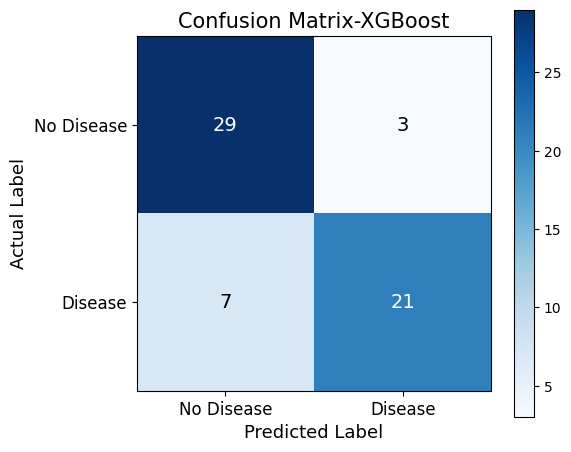

In [ ]:
# ----- CONFUSION MATRIX -----
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix-XGBoost', fontsize=15)
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No Disease', 'Disease'], fontsize=12)
plt.yticks(tick_marks, ['No Disease', 'Disease'], fontsize=12)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('Actual Label', fontsize=13)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=14)
plt.tight_layout()
plt.grid(False)
plt.show()

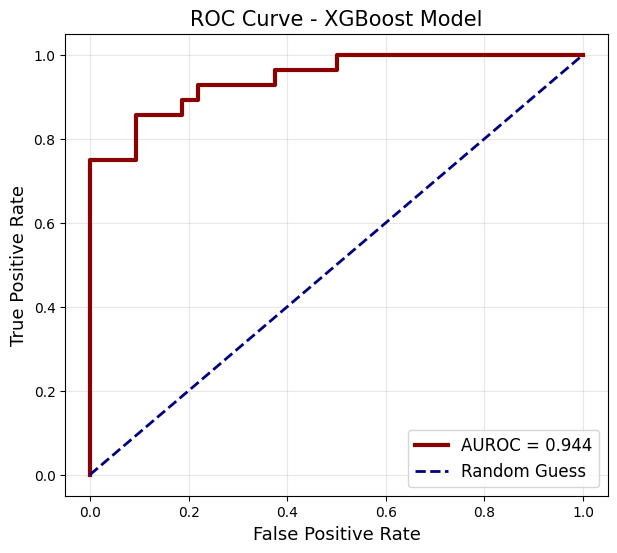

In [ ]:
# ----- ROC CURVE -----

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_value = roc_auc_score(y_test, y_proba) # Fixed: Assigned the actual AUROC score to auc_value

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkred', lw=3, label=f'AUROC = {auc_value:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - XGBoost Model', fontsize=15)
plt.legend(loc='lower right', fontsize=12)


plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ----- Predict for a random patient -----
import random
rand_index = random.randint(0, X_test.shape[0]-1)
patient_features = X_test.iloc[rand_index].values.reshape(1, -1)
true_label = y_test.iloc[rand_index]
pred_prob = best_model.predict_proba(patient_features)[0][1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
# Youden Index
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print("Optimal Threshold:", optimal_threshold)
pred_class = int(pred_prob >= optimal_threshold)
print("\nRandom Patient Details:")
print(X_test.iloc[rand_index])

print("\nTrue Condition:", "Heart Disease" if true_label == 1 else "No Disease")
print(f"Predicted Probability of Heart Disease: {pred_prob*100:.2f}%")
print("Predicted Class:", "Heart Disease" if pred_class == 1 else "No Disease")

Optimal Threshold: 0.3575308

Random Patient Details:
age          66.0
sex           0.0
cp            3.0
trestbps    178.0
chol        228.0
fbs           1.0
restecg       0.0
thalach     165.0
exang         1.0
oldpeak       1.0
slope         1.0
ca            2.0
thal          2.0
Name: 167, dtype: float64

True Condition: Heart Disease
Predicted Probability of Heart Disease: 85.70%
Predicted Class: Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import joblib
import os

# FIRST: recalculate Youden's J properly here (it was only done in the random patient cell before)
from sklearn.metrics import roc_curve
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"XGBoost Optimal Threshold (Youden's J): {optimal_threshold:.4f}")

# Recalculate metrics at optimal threshold (for consistency with PRD)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
print(f"Accuracy at optimal threshold: {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_optimal):.4f}")
print(f"AUROC: {roc_auc_score(y_test, y_proba):.4f}")

# Save the full Pipeline (StandardScaler + XGBoost)
os.makedirs('pkl_files', exist_ok=True)
joblib.dump(best_model, 'pkl_files/xgb.pkl')

# Verify
loaded = joblib.load('pkl_files/xgb.pkl')
test_prob = loaded.predict_proba(X_test[:1])[0][1]
print(f"XGBoost pkl verified. Sample prob: {test_prob:.4f}")
print("XGBoost pipeline (with scaler) saved successfully.")

XGBoost Optimal Threshold (Youden's J): 0.3575
Accuracy at optimal threshold: 0.8833
Precision: 0.8889
Recall: 0.8571
AUROC: 0.9442
XGBoost pkl verified. Sample prob: 0.2750
XGBoost pipeline (with scaler) saved successfully.
